In [1]:
import pandas as pd

In [2]:
import torch
from torch import nn, optim

In [3]:
from sklearn.feature_extraction.text import CountVectorizer

In [4]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

In [5]:
import random

In [6]:
import numpy as np

In [7]:
import matplotlib.pyplot as plot

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
df = pd.read_csv("D:/git/dados/nlp/news_sentiment_analysis.csv", encoding="utf-8")

In [10]:
df = df[["Description", "Sentiment"]]
df

,Description,Sentiment
0,"ST. GEORGE — Kaitlyn Larson, a first-year teac...",positive
1,"Harare, Zimbabwe – Local businesses are grappl...",neutral
2,(marketscreener.com) Billionaire Elon Musk has...,positive
3,(marketscreener.com) A U.S. trade regulator on...,negative
4,4.5 million households in the U.S. have solar ...,positive
...,...,...
3495,QRG Capital Management Inc. increased its stak...,positive
3496,QRG Capital Management Inc. bought a new posit...,positive
3497,QRG Capital Management Inc. boosted its stake ...,positive
3498,"WESTFORD, Mass., July 18, 2024 /PRNewswire/ --...",neutral


In [11]:
df["Sentiment"].unique()

array(['positive', 'neutral', 'negative'], dtype=object)

In [19]:
# mapping_type = {
#         'Business': [1, 0, 0, 0, 0, 0, 0], 
#         'Entertainment': [0, 1, 0, 0, 0, 0, 0], 
#         'General': [0, 0, 1, 0, 0, 0, 0], 
#         'Health': [0, 0, 0, 1, 0, 0, 0], 
#         'Science': [0, 0, 0, 0, 1, 0, 0], 
#         'Sports': [0, 0, 0, 0, 0, 1, 0], 
#         'Technology': [0, 0, 0, 0, 0, 0, 1]
# } 
# df["type_number"] = df["Type"].map( mapping_type )

mapping_type = {
        'positive': 1, 
        'negative': 0, 
        'neutral': 0
}
df["sentiment_number"] = df["Sentiment"].map( mapping_type )

In [15]:
# encoder = LabelEncoder()

In [ ]:
# Y_label = encoder.fit_transform(df["Sentiment"])

In [22]:
# Y_label = torch.tensor(df["sentiment_number"]).reshape(-1, 1)
# Y_label

tensor([1, 0, 1,  ..., 1, 0, 1])

In [23]:
# Y = oh_encoder.fit_transform(Y_label)
# oh_encoder.categories_

In [ ]:
#         'Business': [1, 0, 0, 0, 0, 0, 0], 
#         'Entertainment': [0, 1, 0, 0, 0, 0, 0], 
#         'General': [0, 0, 1, 0, 0, 0, 0], 
#         'Health': [0, 0, 0, 1, 0, 0, 0], 
#         'Science': [0, 0, 0, 0, 1, 0, 0], 
#         'Sports': [0, 0, 0, 0, 0, 1, 0], 
#         'Technology': [0, 0, 0, 0, 0, 0, 1]

In [36]:
# Y = torch.tensor(df["type_number"], dtype=torch.float32)
# Y = torch.reshape( Y, (-1, 1) )
# Y.shape
Y = torch.tensor(df["sentiment_number"], dtype=torch.float32)
Y = Y.reshape(-1, 1)
Y

tensor([[1.],
        [0.],
        [1.],
        ...,
        [1.],
        [0.],
        [1.]])

In [37]:
MAX_PALAVRAS = 2000

In [38]:
vetorizador = CountVectorizer(max_features = MAX_PALAVRAS)

In [39]:
X = vetorizador.fit_transform( df["Description"] )
X = torch.tensor(X.toarray(), dtype=torch.float32)
X

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

In [40]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state = 75)

In [41]:
print(f"{Y_train[0]}  -  {X_train[0]}")

tensor([1.])  -  tensor([0., 0., 0.,  ..., 0., 0., 0.])


In [42]:
vocabulario = vetorizador.get_feature_names_out()
vocabulario

array(['00', '000', '01', ..., 'überkauft', 'überverkauft', 'überwiegend'],
      shape=(2000,), dtype=object)

In [43]:
modelo = nn.Sequential(
    nn.Linear(in_features = MAX_PALAVRAS, out_features = 1),
    nn.Sigmoid()
)
otimizador = optim.SGD( modelo.parameters(), lr=1)
criterio = nn.BCELoss() # Bionary Cross Entropy Perda

In [44]:
lista_loss = []
for epoca in range(2000):
    y_hat = modelo( X_train ) 
    loss = criterio( y_hat, Y_train )
    lista_loss.append( loss )
    if epoca % 100 == 0:
        print(f"Loss: {loss}")
    otimizador.zero_grad()
    loss.backward()
    otimizador.step()

Loss: 0.6794722080230713
Loss: 0.2995258867740631
Loss: 0.23824085295200348
Loss: 0.20255403220653534
Loss: 0.17809051275253296
Loss: 0.1598636507987976
Loss: 0.14557087421417236
Loss: 0.1339665949344635
Loss: 0.12430336326360703
Loss: 0.11609901487827301
Loss: 0.10902544111013412
Loss: 0.10284993797540665
Loss: 0.0974019393324852
Loss: 0.09255305677652359
Loss: 0.08820442855358124
Loss: 0.08427852392196655
Loss: 0.08071356266736984
Loss: 0.07745961844921112
Loss: 0.07447585463523865
Loss: 0.07172849774360657


C:\Users\anton\AppData\Local\Temp\ipykernel_46264\479406149.py:1: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  lista_tensor = torch.tensor( lista_loss )


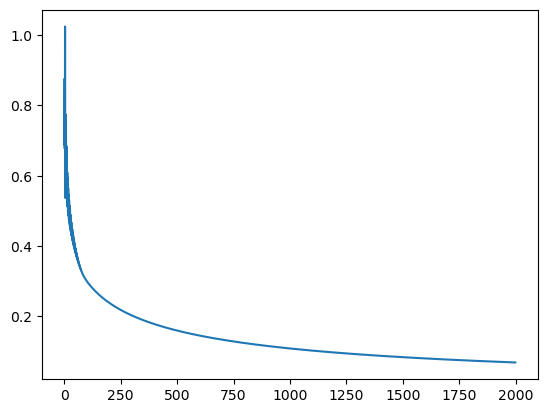

In [45]:
lista_tensor = torch.tensor( lista_loss ) 
plot.plot( lista_tensor )

In [57]:
with torch.no_grad():
    tp = 0
    tn = 0
    fp = 0
    fn = 0
    Y_hat_test = modelo( X_test )
    Y_hat_test_round = np.round(Y_hat_test)
    for idx, y_hat in enumerate(Y_hat_test_round):
        y_test = Y_test[idx]
        if y_hat == 1 and y_test == 1:
            tp = tp + 1
        elif y_hat == 1 and y_test == 0:
            fp = fp + 1
        elif y_hat == 0 and y_test == 1:
            fn = fn + 1
        elif y_hat == 0 and y_test == 0:
            tn = tn + 1
    # print(erros)
    print(f"TP: {tp}\tTN: {tn}\tFP: {fp}\tFN: {fn}")
    precision = tp / (tp + fp)
    print(f"Precision: {precision}")
    recall = tp / (tp + fn)
    print(f"Recall: {recall}")
    acuracy = (tp + tn) / (tp + tn + fp + fn)
    print(f"Acuracy: {acuracy}")

TP: 405	TN: 236	FP: 28	FN: 31
Precision: 0.9353348729792148
Recall: 0.9288990825688074
Acuracy: 0.9157142857142857


In [51]:
posicao = random.randint(0, 3500)
tipo_correto = df["Sentiment"][posicao]
texto = df["Description"][posicao]
print(posicao, ":", tipo_correto, "<->", texto)
# texto =  "trade war occurs in all world, causing faminy and disgrace" # df["Description"][900]
# resultado = df["sentiment_number"][900]
# print(f"Resultado: {resultado}\t\tDescricao: {texto}")

2976 : neutral <-> Köln (ots) - Sie wollen doch nur spielen! Aber bei dieser brandneuen Spielshow aus der Feder von TV-Mastermind Stefan Raab bekommen es die Teilnehmer "voll auf die Zwölf", moderiert von Publikumsli...


In [52]:
vetorizador_teste = CountVectorizer( vocabulary = vocabulario, max_features = MAX_PALAVRAS )
X_teste = vetorizador_teste.fit_transform( [texto] )
X_teste = torch.tensor( [X_teste.toarray()], dtype=torch.float32 )
X_teste.shape

C:\Users\anton\AppData\Local\Temp\ipykernel_46264\1527271665.py:3: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  X_teste = torch.tensor( [X_teste.toarray()], dtype=torch.float32 )


torch.Size([1, 1, 2000])

In [53]:
Y_hat_teste = modelo( X_teste )
resultado = Y_hat_teste.detach().numpy()
indice = np.argmax(resultado)
tipo = encoder.inverse_transform( [indice] )
print(f"Indice: {indice}\tTipo: {tipo}")

Indice: 0	Tipo: ['negative']
